In [63]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.custom_primitives.random_variable import rv
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.helpers import Flip, Context

import optax
from optax import adam

import jax
from jax import numpy as jnp


In [64]:
def simulator_two_moons(key, theta0, theta1):
    """Simulator for the two moons problem."""
    key1, key2 = jax.random.split(key)
    p = Normal(0.1, 0.01)
    u = Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi)
    noise1 = rv(p, "r")
    noise2 = rv(u, "alpha")
    r = noise1(key1)
    alpha = noise2(key2)
    rhs1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / jnp.sqrt(2.))
    rhs2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / jnp.sqrt(2.))

    return rhs1, rhs2

In [65]:
thetas = Uniform(-1., 1.).sample(jax.random.PRNGKey(0), (100000, 2))
xs = jnp.stack(jax.vmap(simulator_two_moons)(jax.random.split(jax.random.PRNGKey(0), thetas.shape[0]), thetas[:, 0], thetas[:, 1]), axis=1)

# Conditional Normalizing flows

Constructing normalizing flows easily using the inverse interpreter!

In [66]:
context_dim = 2
input_dim = 2

In [67]:
# Base distribution
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

### Affine flows

We have a coupling MLP combined with an affine bijector.

In [73]:
@jax.vmap
def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale) + 0.01
    return loc + scale*x


bijector_dim = 2*(input_dim // 2)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x, context):
    nn = hk.Sequential([CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context), 
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context)])
    return nn(x)

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((1, input_dim)), jnp.zeros((1, context_dim)))

# Parameterized invertibe transformation
T = forward.apply

In [74]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x, context):
    q = TransformedDistribution(p, lambda x: T(params, x, context))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x, context):
    loss, g = jax.value_and_grad(loss_fn)(params, x, context)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [75]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    thetas_batch = jax.random.choice(jax.random.PRNGKey(i), thetas, (1000,))
    params, opt_state, loss = step(params, opt_state, thetas_batch, xs_batch)
    if i % 1000 == 0:
        print(loss)

12.572992
-2.2656417
-2.647807
-2.663001
-2.6864307


In [76]:
def t_conditional(x):
    return jnp.squeeze(jax.vmap(T, in_axes=(None, 0, None))(params, jnp.expand_dims(x, 1), xs[:1]))

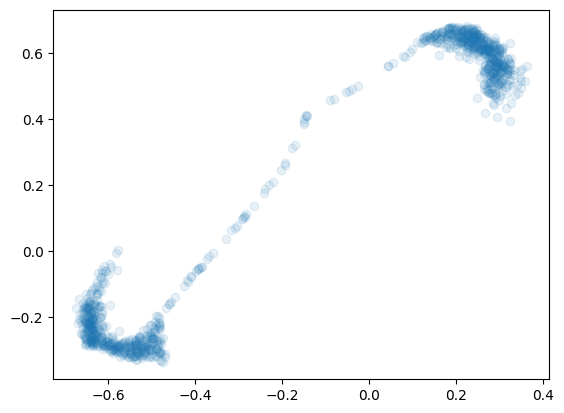

In [77]:
q = TransformedDistribution(p,  t_conditional)
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)

## Spline flows

In [104]:
@jax.vmap
def spline_bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -1., range_max_y=1.)

num_bins = 8
bijector_dim = (3 * num_bins)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x, context):
    nn = hk.Sequential([CouplingMLP(1, spline_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(1, spline_bijector, bijector_dim, context=context), 
                        Flip(), 
                        CouplingMLP(1, spline_bijector, bijector_dim, context=context)])
    return nn(x)

init, apply = forward.init, forward.apply
params = init(jax.random.PRNGKey(0), jnp.ones((10,input_dim,)), jnp.ones((10,context_dim,)))
T = apply

In [107]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x, context):
    q = TransformedDistribution(p, lambda x: T(params, x, context))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x, context):
    loss, g = jax.value_and_grad(loss_fn)(params, x, context)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [108]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    thetas_batch = jax.random.choice(jax.random.PRNGKey(i), thetas, (1000,))
    params, opt_state, loss = step(params, opt_state, thetas_batch, xs_batch)
    if i % 1000 == 0:
        print(loss)

4.906227
-2.2017536
-2.6642776
-2.8667111
-2.2373133


In [109]:
def t_conditional(x):
    return jnp.squeeze(jax.vmap(T, in_axes=(None, 0, None))(params, jnp.expand_dims(x, 1), xs[:1]))

In [110]:
q = TransformedDistribution(p, t_conditional)
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-1.0, 1.0)

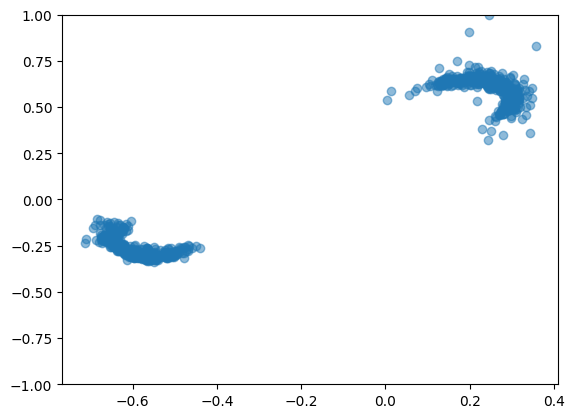

In [111]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.ylim(-1,1)